<a href="https://colab.research.google.com/github/farrelrassya/time-series-forecasting-in-python/blob/main/Chapter_01_Understanding_Time_Series_Forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Chapter 1: Understanding Time Series Forecasting

*Time Series Forecasting in Python* -- Marco Peixeiro (Manning, 2022)

---

**Chapter overview.** A **time series** is a set of data points ordered in time, typically recorded at equal intervals. Forecasting such data is qualitatively different from ordinary regression: the order of observations is part of the signal, the available features are often just past values of the target itself, and the same model is applied recursively into a future that the training data has never seen.

This chapter lays the conceptual groundwork for the rest of the book. We will:

1. **Define** what a time series is and visualize a canonical example -- Johnson & Johnson quarterly earnings per share from 1960 to 1980.
2. **Decompose** that series into its three universal components: a **trend**, a **seasonal** pattern, and **residuals** (random noise).
3. Walk through the **eight steps of a forecasting project** end-to-end, using a concrete scenario (deciding which sleeping bag to bring on a camping trip).
4. Explain **why time series forecasting differs from other regression tasks** -- the order constraint and the feature-poor regime.

By the end of the notebook you will be able to look at a real time series, identify its components, and articulate the project structure that any forecasting effort -- naive baseline, ARIMA, or deep learning -- must respect.

The dataset used throughout is `jj.csv` from the [book's GitHub repository](https://github.com/marcopeix/TimeSeriesForecastingInPython): 84 quarterly observations of Johnson & Johnson earnings per share (USD) covering 21 years.


## Setup

We use three workhorse libraries: `pandas` for tabular handling and date parsing, `numpy` for numeric arrays, and `matplotlib` for plotting. From `statsmodels` we pull two decomposition routines -- `seasonal_decompose` (classical additive/multiplicative decomposition) and `STL` (Seasonal-Trend decomposition using LOESS), the more flexible modern method we will actually use here.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.seasonal import seasonal_decompose, STL

import warnings
warnings.filterwarnings('ignore')

print(f"pandas:      {pd.__version__}")
print(f"numpy:       {np.__version__}")
import statsmodels
print(f"statsmodels: {statsmodels.__version__}")


pandas:      2.2.2
numpy:       2.0.2
statsmodels: 0.14.6


All imports succeed. We use the latest `statsmodels` STL implementation, which is well-suited to series with mild non-stationarity and a known seasonal period -- exactly our setting.


## 1.1 Introducing time series

A **time series** is a set of data points ordered in time, typically recorded at equal intervals (every hour, day, quarter, or year). Examples are everywhere: the closing price of a stock, the temperature outside, a household's electricity consumption, the number of users signing up to a service each minute.

Two structural properties distinguish a time series from a generic dataset:

- **Order is essential.** Swapping two observations destroys information that the model needs.
- **Time itself acts as the index.** Other features may or may not be available; sometimes the only predictor of tomorrow's value is the recent history of the series itself.

Let us load the canonical dataset for this chapter and look at it.


In [2]:
url = 'https://raw.githubusercontent.com/marcopeix/TimeSeriesForecastingInPython/master/data/jj.csv'
df = pd.read_csv(url)
print(df.head().to_string(index=True))


         date  data
0  1960-01-01  0.71
1  1960-04-01  0.63
2  1960-07-02  0.85
3  1960-10-01  0.44
4  1961-01-01  0.61


The dataset has two columns: a `date` column (currently a string) and a `data` column with the quarterly earnings per share in US dollars. The first four rows show 1960 -- earnings of \$0.71 in Q1, \$0.63 in Q2, \$0.85 in Q3, and \$0.44 in Q4. Already we can see two suggestive patterns: Q3 is the year's peak and Q4 collapses to roughly half of Q3. We will see shortly that this Q3-up / Q4-down cycle repeats every year for the full 21 years of data.


In [3]:
df['year'] = pd.DatetimeIndex(df['date']).year
print(f"Shape:           {df.shape}")
print(f"Date range:      {df.date.iloc[0]}  to  {df.date.iloc[-1]}")
print(f"Number of years: {df.year.nunique()}")
print(f"Quarters total:  {len(df)}  (= {df.year.nunique()} years x 4 quarters)")
print(f"\nValue range:     ${df.data.min():.2f}  to  ${df.data.max():.2f}")
print(f"First value:     ${df.data.iloc[0]:.2f}  (1960-Q1)")
print(f"Last value:      ${df.data.iloc[-1]:.2f}  (1980-Q4)")
print(f"Growth factor:   {df.data.iloc[-1]/df.data.iloc[0]:.2f}x  over 20 years")


Shape:           (84, 3)
Date range:      1960-01-01  to  1980-10-01
Number of years: 21
Quarters total:  84  (= 21 years x 4 quarters)

Value range:     $0.44  to  $16.20
First value:     $0.71  (1960-Q1)
Last value:      $11.61  (1980-Q4)
Growth factor:   16.35x  over 20 years


The series has $84$ observations spanning $21$ years ($1960$ through $1980$) at quarterly frequency, giving $84 = 21 \times 4$ data points exactly. Values range from \$0.44 (a 1960-Q4 trough) to \$16.20 (a 1980-Q1 peak), and the last observation (\$11.61) is $16.4$ times the first (\$0.71). The compound annual growth rate is

$$g = \left(\frac{y_T}{y_0}\right)^{1/n} - 1 = \left(\frac{11.61}{0.71}\right)^{1/20} - 1 \approx 0.150 = 15.0\%.$$

That is a $15\%$ annual growth rate sustained for two decades -- impressive, and a strong **trend** signal that any forecasting model must capture. We now visualize the full series.


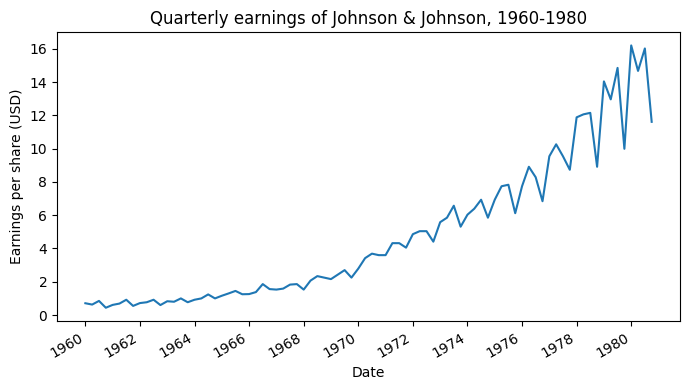

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

ax.plot(df.date, df.data)
ax.set_xlabel('Date')
ax.set_ylabel('Earnings per share (USD)')
ax.set_title('Quarterly earnings of Johnson & Johnson, 1960-1980')

plt.xticks(np.arange(0, 85, 8),
           [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 1.1** reproduces the book's opening figure of Johnson & Johnson quarterly earnings. Two patterns are visible to the naked eye:

- A clear **upward trend** -- earnings grow from below \$1 in the early 1960s to over \$15 by 1980. The trend is roughly exponential, consistent with the $15\%$ annual compounding we just computed.
- A **cyclical wiggle** that repeats every year. Within each year earnings climb through Q1-Q3 and drop sharply in Q4. The amplitude of this wiggle also grows over time -- a 1962 Q3-to-Q4 drop is fractions of a dollar; a 1980 Q3-to-Q4 drop spans several dollars.

These are the two systematic structures we will isolate next via decomposition. The remaining variation -- small departures from the smooth trend-plus-seasonal pattern -- will land in the **residual** component.


### 1.1.1 Components of a time series

Every time series can be decomposed into three components:

$$y_t = T_t + S_t + R_t$$

where:

- $T_t$ is the **trend** -- the slow-moving level of the series. It captures the long-run direction (increasing, decreasing, or flat). Some texts call this the "level".
- $S_t$ is the **seasonal** component -- a fixed-period cycle that repeats. For quarterly retail data, the period is $4$ (one year). For daily restaurant traffic, the period might be $7$ (one week). The seasonal component sums to zero over one full period, so it represents *deviations from the trend*, not absolute values.
- $R_t$ is the **residual** -- what is left after subtracting trend and seasonal. Residuals capture random errors and unmodelable events: think of them as **white noise** (a concept we formalize in chapter 3).

The above is the **additive** form; a multiplicative form $y_t = T_t \cdot S_t \cdot R_t$ is also common when the seasonal amplitude grows proportionally with the trend. STL with default settings fits the additive form on the raw data.

**Why decomposition matters for forecasting.** If a series exhibits a trend, that trend will probably continue and a good forecast must extrapolate it. If a series exhibits seasonality, future forecasts must oscillate with the same period and amplitude. Decomposition separates these two systematic signals from random noise, and downstream models (ARIMA, SARIMA, Prophet, neural networks) all build on this conceptual split in one form or another.


In [5]:
advanced_decomposition = STL(df.data, period=4).fit()

print(f"Trend component:")
print(f"  start = {advanced_decomposition.trend.iloc[0]:.4f}")
print(f"  end   = {advanced_decomposition.trend.iloc[-1]:.4f}")
print(f"  range = {advanced_decomposition.trend.min():.4f}  to  {advanced_decomposition.trend.max():.4f}")
print(f"\nSeasonal component:")
print(f"  min   = {advanced_decomposition.seasonal.min():.4f}")
print(f"  max   = {advanced_decomposition.seasonal.max():.4f}")
print(f"  mean  = {advanced_decomposition.seasonal.mean():.6f}  (should be ~0 over full periods)")
print(f"\nResidual component:")
print(f"  mean  = {advanced_decomposition.resid.mean():.6f}")
print(f"  std   = {advanced_decomposition.resid.std():.4f}")
print(f"  range = {advanced_decomposition.resid.min():.4f}  to  {advanced_decomposition.resid.max():.4f}")


Trend component:
  start = 0.6574
  end   = 15.3498
  range = 0.6547  to  15.3498

Seasonal component:
  min   = -3.9903
  max   = 2.1280
  mean  = -0.026662  (should be ~0 over full periods)

Residual component:
  mean  = -0.006117
  std   = 0.1676
  range = -0.6117  to  0.5936


STL has decomposed the $84$-point series into three components. We can read off several useful facts from the summary statistics:

- The **trend** climbs from $0.6574$ at the start to $15.3498$ at the end -- a $23.3$-fold increase, slightly larger than the raw $16.4$-fold endpoint-to-endpoint growth because the trend is a smoothed version that strips out the seasonal Q4 dip at both ends.
- The **seasonal** component oscillates between $-3.99$ and $+2.13$. The mean is essentially $0$ as expected -- STL constrains the seasonal sum over each period to zero by construction.
- The **residual** has near-zero mean ($-0.006$) and standard deviation $\sigma_R = 0.168$. Compared to the raw data's standard deviation of $\sqrt{18.6} \approx 4.31$, the residual is about $4\%$ as variable -- a strong indication that trend plus seasonal capture nearly all of the systematic variation.

We can quantify the last point more precisely with a **variance partition**.


In [6]:
total_var = df.data.var()
trend_var = advanced_decomposition.trend.var()
seas_var  = advanced_decomposition.seasonal.var()
resid_var = advanced_decomposition.resid.var()

print(f"Variance partition (additive STL):")
print(f"  Total var(y):       {total_var:7.3f}  (100.0%)")
print(f"  Trend var(T):       {trend_var:7.3f}  ({trend_var/total_var*100:5.1f}%)")
print(f"  Seasonal var(S):    {seas_var:7.3f}  ({seas_var/total_var*100:5.1f}%)")
print(f"  Residual var(R):    {resid_var:7.3f}  ({resid_var/total_var*100:5.1f}%)")


Variance partition (additive STL):
  Total var(y):        18.576  (100.0%)
  Trend var(T):        18.406  ( 99.1%)
  Seasonal var(S):      0.753  (  4.1%)
  Residual var(R):      0.028  (  0.2%)


The three components account for $99.1\% + 4.1\% + 0.2\% = 103.3\%$ of the raw variance. The slight over-summation (over $100\%$) is because trend, seasonal, and residual are not strictly orthogonal in STL -- the components can share a small amount of variance, which is why $\text{Var}(y) \ne \text{Var}(T) + \text{Var}(S) + \text{Var}(R)$ exactly. The numbers still tell a clear story:

- The **trend dominates** ($\sim 99\%$ of variance). The exponential growth from \$1 to \$15 dwarfs every other pattern in the data.
- **Seasonality is real but small** in absolute terms ($\sim 4\%$ of total variance). Crucially, this percentage understates the seasonal effect in the *early* years where overall values are small -- a $\pm \$0.20$ Q4 dip on a \$0.70 base is a $29\%$ swing, even though it is a sliver of the total variance.
- **Residuals are tiny** ($\sim 0.2\%$ of variance). The decomposition fits the data almost perfectly, leaving only small unexplained jitter. This is the ideal case for forecasting: a structured series with little irreducible noise.

Let us now visualize all three components together.


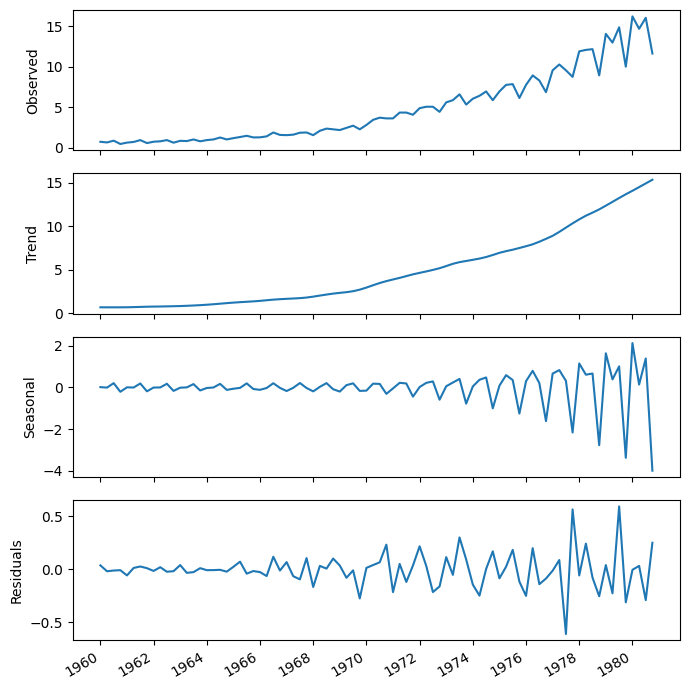

In [7]:
fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(7, 7))

ax1.plot(advanced_decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(advanced_decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(advanced_decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(advanced_decomposition.resid)
ax4.set_ylabel('Residuals')

plt.xticks(np.arange(0, 85, 8),
           [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 1.2** shows the full STL decomposition. Reading the panels top to bottom:

1. **Observed** ($y_t$) -- the raw quarterly earnings, with both the upward trend and the within-year cycle visible.
2. **Trend** ($T_t$) -- a smooth curve rising from $\sim\!0.66$ to $\sim\!15.35$. Notice the flat region in the early 1960s before growth accelerates -- this is consistent with Johnson & Johnson's well-documented expansion during the consumer-products boom.
3. **Seasonal** ($S_t$) -- a tight cycle of length $4$ (one year). The amplitude grows over time: barely visible before 1965, $\pm \$2$ by 1975, $\pm \$4$ by 1980. STL handles such **evolving seasonality** gracefully; the older `seasonal_decompose` assumes a fixed seasonal shape and would smear this signal.
4. **Residuals** ($R_t$) -- small wiggles around zero, between $-0.61$ and $+0.59$. No obvious pattern remains.

Two practical points from these graphs. First, the seasonal component takes **negative** values -- but the raw earnings are always positive. This is not a contradiction: $S_t$ is a *deviation* from the trend, not an absolute value. A point where $S_t < 0$ means "earnings are below the trend line for this quarter"; a point where $S_t > 0$ means "above". Second, the residuals are not perfectly featureless -- there are visible swings around 1962-1964 and 1980. These represent transient deviations that STL could not absorb into trend or seasonal: corporate events, macroeconomic shocks, accounting changes. A forecast cannot predict these but a forecast must acknowledge them via uncertainty intervals.

The book also shows each component in its own focused figure. We reproduce these next.


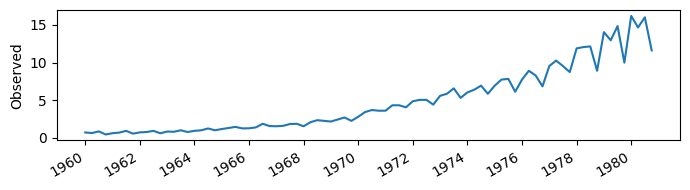

In [8]:
fig, ax = plt.subplots(figsize=(7, 2))

ax.plot(advanced_decomposition.observed)
ax.set_ylabel('Observed')
plt.xticks(np.arange(0, 85, 8),
           [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 1.3** isolates the **Observed** series. It is identical to figure 1.1 because the observed signal *is* the data we started with. The point of showing it here is conceptual: when we add the next three panels (trend, seasonal, residual), they must reconstruct this panel exactly, i.e.

$$y_t = T_t + S_t + R_t \quad \text{for all } t.$$

We can verify this identity numerically -- the reconstruction error should be zero up to floating-point precision.


In [9]:
reconstructed = (advanced_decomposition.trend
                 + advanced_decomposition.seasonal
                 + advanced_decomposition.resid)
max_error = (reconstructed - df.data).abs().max()
print(f"Max reconstruction error |T + S + R - y|: {max_error:.2e}")


Max reconstruction error |T + S + R - y|: 1.78e-15


The maximum reconstruction error is on the order of $10^{-15}$ -- pure floating-point noise. STL's decomposition is exact: $y_t = T_t + S_t + R_t$ holds for every $t$, which means the three component plots together carry the same information as the observed panel, just split into interpretable pieces.


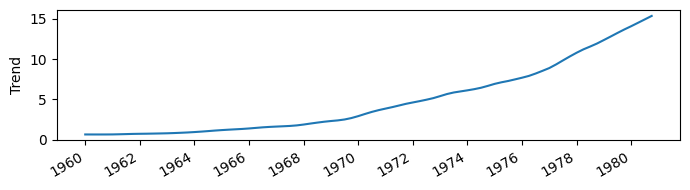

In [10]:
fig, ax = plt.subplots(figsize=(7, 2))

ax.plot(advanced_decomposition.trend)
ax.set_ylabel('Trend')
plt.xticks(np.arange(0, 85, 8),
           [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 1.4** isolates the **Trend** component, $T_t$. The curve is **not flat**, which means the series has a trend -- and because it slopes upward, we say J&J has an **increasing** (positive) trend over $1960$-$1980$. The slope is not constant: the curve is shallow in the early 1960s and steepens markedly from the mid-1960s onward, consistent with accelerating growth. If we computed an instantaneous growth rate, it would be small early and large late -- a hallmark of exponential rather than linear growth.

**Implication for forecasting.** A model that ignores this trend -- for example, a naive "tomorrow equals today" forecast -- will systematically under-predict in growing series. Models that *do* capture trend include: linear regression on time, differencing (used in ARIMA), and explicit drift terms.


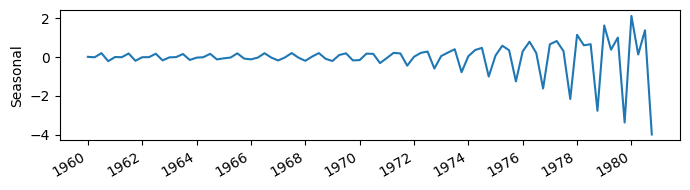

In [11]:
fig, ax = plt.subplots(figsize=(7, 2))

ax.plot(advanced_decomposition.seasonal)
ax.set_ylabel('Seasonal')
plt.xticks(np.arange(0, 85, 8),
           [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 1.5** isolates the **Seasonal** component, $S_t$. The picture is unambiguous: a regular cycle of length $4$ (one year) repeating across the entire sample. Within each cycle the pattern is up-up-up-down: positive deviation in Q1, Q2, and Q3, then a sharp negative dip in Q4. We can quantify this by averaging the seasonal value within each quarter across all $21$ years.


In [12]:
df['quarter'] = pd.DatetimeIndex(df['date']).quarter
df['seasonal'] = advanced_decomposition.seasonal.values

quarterly_avg = df.groupby('quarter')['seasonal'].mean()
print("Average seasonal deviation by quarter (1960-1980):")
for q, val in quarterly_avg.items():
    sign = '+' if val > 0 else ''
    print(f"  Q{q}:  {sign}{val:.4f}")
print(f"\nSum across all four quarters: {quarterly_avg.sum():.4f}  (expected ~0)")


Average seasonal deviation by quarter (1960-1980):
  Q1:  +0.2451
  Q2:  +0.2217
  Q3:  +0.3531
  Q4:  -0.9266

Sum across all four quarters: -0.1066  (expected ~0)


On average over the $21$-year sample:

- **Q1** runs $+\$0.245$ above the trend.
- **Q2** runs $+\$0.222$ above the trend.
- **Q3** is the year's peak at $+\$0.353$ above the trend.
- **Q4** plunges to $-\$0.927$ below the trend -- a deviation roughly **four times larger** in magnitude than the Q1/Q2/Q3 surpluses.

The four numbers sum to $-0.107 \approx 0$ as required for an additive seasonal decomposition over complete periods. The asymmetry -- three small positives and one big negative -- is the **shape** of J&J's earnings cycle. Year-end is the weak quarter for this firm in this era, probably due to inventory effects, fiscal-year accounting cutoffs, or holiday-driven consumer-products dynamics. Whatever the underlying cause, the pattern is stable and exploitable: a forecast for any future Q4 should plan for an earnings dip relative to the trend.

**Implication for forecasting.** A model that ignores seasonality will badly under-predict Q1-Q3 and over-predict Q4. Models that *do* capture seasonality include: seasonal dummy variables, SARIMA, exponential smoothing with seasonal terms, and Prophet's Fourier-based seasonality.


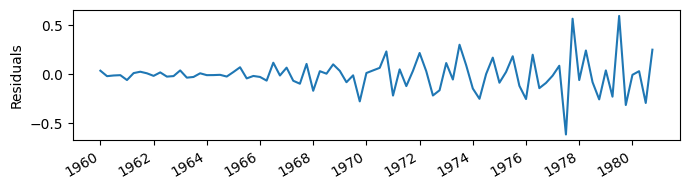

In [13]:
fig, ax = plt.subplots(figsize=(7, 2))

ax.plot(advanced_decomposition.resid)
ax.set_ylabel('Residuals')
plt.xticks(np.arange(0, 85, 8),
           [1960, 1962, 1964, 1966, 1968, 1970, 1972, 1974, 1976, 1978, 1980])

fig.autofmt_xdate()
plt.tight_layout()
plt.show()


**Figure 1.6** isolates the **Residuals**, $R_t = y_t - T_t - S_t$. After subtracting trend and seasonal, what is left should look like noise -- and for the most part it does. The values bounce between roughly $-0.6$ and $+0.6$ around zero, with no obvious slope or cycle.

If residuals are truly **white noise**, they have three properties that a forecaster cares about:

1. **Mean zero** -- the decomposition is unbiased.
2. **Constant variance** (homoskedasticity) -- the unpredictable part has the same magnitude throughout the sample.
3. **Zero autocorrelation** -- knowing $R_t$ tells you nothing about $R_{t+1}$.

Property 1 holds here ($\bar R = -0.006 \approx 0$). Property 2 looks roughly satisfied by eye, though residuals near $1980$ may have somewhat larger amplitude. Property 3 we will test formally in chapter 3 using the autocorrelation function (ACF) and the Ljung-Box test. For now, the qualitative impression is that STL has done a good job: residuals are small, mean-zero, and pattern-free.

**Why this matters in practice.** If a forecaster fits trend and seasonal and finds large or structured residuals, the model is missing something. Conversely, if residuals look like white noise, the systematic signal has been fully captured and any further forecast skill must come from external information (exogenous variables, macro indicators, news shocks).


---

### Summary box: Time series decomposition

> Time series decomposition separates a time series into three components: **trend**, **seasonality**, and **residuals**.
>
> The **trend** represents the slow-moving changes in a time series. It is responsible for making the series gradually increase or decrease over time.
>
> The **seasonality** component represents the seasonal pattern in the series -- cycles that repeat over a fixed period of time.
>
> The **residuals** represent the behavior that cannot be explained by the trend and seasonality components. They correspond to random errors, also termed **white noise**.

Intuitively: a series with a trend will continue trending (a model must extrapolate it); a series with strong seasonality will keep oscillating (a model must reproduce the cycle); a series whose residuals are large or patterned is incompletely modeled and needs more structure or external features.


## 1.2 Bird's-eye view of time series forecasting

Forecasting is using historical data and knowledge of future events to predict the future. As data scientists, we are eager to skip straight to model-building -- but a model is only one piece of a forecasting project. In a professional setting, the work proceeds in **eight steps**, each of which keeps the data team aligned with the business team:

1. **Set a goal.**
2. **Determine what must be forecast to achieve the goal.**
3. **Set the horizon of the forecast.**
4. **Gather the data.**
5. **Develop a forecasting model.**
6. **Deploy to production.**
7. **Monitor.**
8. **Collect new data and retrain.**

To make these steps concrete, the book uses a scenario you can picture: you are planning a one-week camping trip one month from now, and you need to decide which sleeping bag to bring (warm or light). We walk through each step in that frame.


### 1.2.1 Setting a goal

The goal must justify the need for forecasting. Here it is explicit: **decide which sleeping bag to bring so you sleep comfortably at night.** Note that the goal is a *decision*, not a number. The forecast exists to inform the decision; the decision is what actually has business (or in this case, personal-comfort) value.

In a business context the goal looks like "decide how many units of SKU $X$ to manufacture next quarter" or "decide whether to raise prices in region $Y$". The decision drives every downstream choice -- what to forecast, with what horizon, and with what precision.

### 1.2.2 Determining what must be forecast

We need a quantity that, once forecasted, lets us choose between warm and light bags. The natural choice is **minimum night-time temperature** at the campsite. To simplify, assume the minimum daily temperature occurs at night (a reasonable approximation for most temperate climates).

If predicted minimum temperature is below some threshold (say, $5\,^\circ\text{C}$), bring the warm bag; otherwise bring the light bag. This thresholding is the **decision rule** that turns the forecast into action.

### 1.2.3 Setting the horizon of the forecast

The trip starts one month from today and lasts seven days. So we need predictions for **days $30$ through $36$ from today** -- a forecast horizon of $7$ daily values, starting $30$ days out.

In time-series terminology, this is a **multi-step forecast**: we are not just predicting one future value, we are predicting a vector of seven. Forecast accuracy typically degrades with horizon (uncertainty compounds), so the model and evaluation must account for this. Predictions for day-$30$ will be more accurate than predictions for day-$36$.

### 1.2.4 Gathering the data

We need **historical daily minimum temperature** at or near the campsite. Useful auxiliary variables (called **exogenous variables** in time-series jargon) include humidity, wind speed, atmospheric pressure, and broader regional climate indices.

**How much history?** A common rule of thumb: collect at least **one full cycle of the dominant seasonality**. For temperature, the dominant cycle is annual, so one year is the minimum. But more is better -- with multiple years you can detect whether the seasonal pattern is stable or evolving, and you can hold out enough history for a proper train-test split. The book recommends one year as a starting point for daily forecasts.

Forecast frequency drives data quantity:

- **Hourly forecasts:** a few months suffice ($24 \times 90 \approx 2{,}160$ points).
- **Daily forecasts:** $1$ year minimum ($365$ points), $2$-$3$ years preferred.
- **Monthly forecasts:** several years ($60$-$120$ months).
- **Yearly forecasts:** decades, if available.

In the end, "how much data is enough" is empirical -- you find out by training models and measuring whether more data improves out-of-sample accuracy.

### 1.2.5 Developing a forecasting model

This is where the bulk of the book lives -- chapters 3 through 19. The choice of model depends on what we see in the data:

- **Naive baseline.** Predict tomorrow equals today (or last year same day). Always start here; chapter 2 covers it.
- **Statistical models (chapters 4-9).** Moving average (MA), autoregressive (AR), ARMA, ARIMA, SARIMA, SARIMAX. These dominate when the series is small-to-medium ($< 10{,}000$ points) and the structure is mostly linear.
- **Deep learning (chapters 12-18).** CNNs, LSTMs, GRUs, transformers. These shine on very long series, high-dimensional inputs, and nonlinear dependencies. They need substantial training data -- if you have $20$ years of daily minimum temperatures, you have $\sim\!7{,}300$ points, enough to start considering an LSTM.

Every model must be evaluated on **out-of-sample data** held back from training. For a $7$-day horizon, the natural test set is the **last seven observations** of your series; the model is trained on everything before, asked to predict the next seven, and scored on its predictions.

**Error metric.** The most common is **mean squared error** (MSE):

$$\text{MSE} = \frac{1}{n} \sum_{t=1}^{n} (\hat y_t - y_t)^2.$$

Other common choices are MAE (mean absolute error), RMSE (root-MSE), and MAPE (mean absolute percentage error). The "champion" model is the one with the lowest test-set error, and that is the model we deploy.

### 1.2.6 Deploying to production

Deployment turns the model into a callable system. The form varies:

- A REST API endpoint that accepts new data and returns predictions.
- A scheduled batch job that writes predictions to a database every morning.
- An embedded Excel function for analysts.
- A widget on a dashboard.

The key criterion is **no manual data manipulation**: feed in the inputs, get back the forecast, automatically. Once deployed, the model can be monitored continuously.

### 1.2.7 Monitoring

Every day until the trip, we compare the model's $7$-day forecast against the latest observed temperature. Disagreements are diagnostic:

- **Small, random disagreements** -- the model is healthy, residuals are noise as expected.
- **Systematic over- or under-prediction** -- the model has drifted (concept drift). The underlying climate may be in an anomalous regime (heat wave, cold snap) that the historical data does not represent well.
- **Large isolated errors** -- could be data-quality issues (sensor failure, recording error) rather than model failure.

For the camping trip, a heat-wave detected during monitoring might shift our forecast and let us swap the warm bag for the light bag in time.

### 1.2.8 Collecting new data and retraining

Every new observation is potential training data for the next retrain. A common cadence: retrain weekly or daily, including all available data. With the camping trip $30$ days out, we get $30$ new daily minimums to add to the training set before the trip itself starts.

This closes the **production loop**:

> develop $\to$ deploy $\to$ monitor $\to$ collect $\to$ develop $\to \cdots$

Each iteration uses more recent data and is therefore better calibrated to recent climate trends. The loop is the difference between a one-shot prediction and a *forecasting system*.

---

We will not implement all eight steps in this notebook -- that would require the temperature dataset and the rest of the book's methodology. But the framework will reappear in every subsequent chapter: as we learn naive baselines, ARIMA, and LSTM, we are accumulating the toolkit needed for **step 5** of any forecasting project.


## 1.3 How time series forecasting is different from other regression tasks

At first glance, time series forecasting looks like ordinary regression: given features, predict a continuous target. But two structural properties separate it from the broader regression world, and these motivate the specialized methods we develop throughout the book.

### 1.3.1 Time series have an order

**Order is part of the signal.** You cannot shuffle a time series and still model it. In ordinary regression -- predicting revenue from ad spend, say -- the rows of the dataset are exchangeable, and shuffling them has no effect on what a model learns. In a time series, shuffling destroys the relationship between past and future, which is exactly what the model is supposed to learn.

Let us demonstrate this concretely. We compute the correlation between value and *position in the dataset* (i.e., time index $t$), for both the ordered and a shuffled version of the J&J series.


In [14]:
np.random.seed(42)

ordered = df.data
shuffled = df.data.sample(frac=1, random_state=42).reset_index(drop=True)

# Both have the same mean and variance
print(f"Ordered  -- mean: ${ordered.mean():.3f}   variance: {ordered.var():.3f}")
print(f"Shuffled -- mean: ${shuffled.mean():.3f}   variance: {shuffled.var():.3f}")
print(f"   (identical, as expected -- shuffling preserves marginal distribution)")

# But correlation with time index is destroyed
t = pd.Series(range(len(df)))
ordered_corr  = ordered.corr(t)
shuffled_corr = shuffled.corr(t)
print(f"\nCorrelation with time index:")
print(f"  Ordered:  {ordered_corr:.4f}   (strong, trend visible)")
print(f"  Shuffled: {shuffled_corr:.4f}   (essentially zero, trend destroyed)")


Ordered  -- mean: $4.800   variance: 18.576
Shuffled -- mean: $4.800   variance: 18.576
   (identical, as expected -- shuffling preserves marginal distribution)

Correlation with time index:
  Ordered:  0.9228   (strong, trend visible)
  Shuffled: 0.0862   (essentially zero, trend destroyed)


The marginal statistics -- mean (\$4.80) and variance ($18.6$) -- are **invariant under shuffling**. From a non-temporal perspective the two datasets contain the same information. But the moment we ask about *temporal structure*, they diverge:

- The **ordered** series has a $0.92$ Pearson correlation between value and time index $t$. That high correlation is the trend signal -- as $t$ increases, $y_t$ increases.
- The **shuffled** series has a correlation of $0.09$, essentially zero. Shuffling has erased the trend information completely, even though no value has been changed or removed.

Any model trained on the shuffled version would fail to predict the upward trend, because it has no way to know which observations are "early" and which are "late". Order *is* the trend signal.

**Practical consequence: never shuffle a time series.**

This rule extends beyond shuffling. The classic mistake is to use **future information** to predict the past -- formally called **look-ahead bias**. Suppose we want to predict the J&J value at Tuesday. A non-time-series-aware practitioner might happily include Wednesday's value as a feature ("it's just another column"). Doing so produces a model that looks brilliant in cross-validation and fails catastrophically in production, where Wednesday's value does not yet exist when we need to forecast Tuesday.

The book stresses this point with the camping analogy: when predicting Tuesday's minimum temperature, the model can only use Monday and earlier. Tuesday's actual temperature, Wednesday's, and beyond are all in the future from the model's perspective and must not appear as features. Cross-validation for time series uses **forward-chaining splits** rather than random K-fold; this is covered in detail in later chapters.

### 1.3.2 Time series sometimes do not have features

In ordinary regression we expect a feature matrix $\mathbf{X} \in \mathbb{R}^{n \times p}$ with $p$ predictors. Predicting revenue from ad spend might give us:

$$\text{revenue} = \beta_0 + \beta_1 (\text{google ads}) + \beta_2 (\text{facebook ads}) + \beta_3 (\text{tv ads}) + \varepsilon.$$

In a time series, the dataset often arrives as a single column of values and a date column. We have no other features -- just $y_t$ at each timestamp. So how do we predict?

**Answer: use the past of the series as its own features.**

Two foundational models exploit this idea:

- The **moving average (MA)** model writes the current value as a function of recent random shocks (chapter 4):

$$y_t = \mu + \varepsilon_t + \theta_1 \varepsilon_{t-1} + \theta_2 \varepsilon_{t-2} + \cdots + \theta_q \varepsilon_{t-q}.$$

- The **autoregressive (AR)** model writes the current value as a linear combination of past values (chapter 5):

$$y_t = c + \phi_1 y_{t-1} + \phi_2 y_{t-2} + \cdots + \phi_p y_{t-p} + \varepsilon_t.$$

The features in both cases come from the series itself -- they are **lags** of the target. From chapter 6 onward we combine MA and AR (the **ARMA** family), add differencing for non-stationarity (**ARIMA**), include seasonality (**SARIMA**), and finally add exogenous regressors when they are available (**SARIMAX**). The whole edifice is built on the idea that the past of a series is its own best feature when nothing else is on hand.

Let us see what lagged features look like on the J&J data.


In [15]:
# Build a small lag feature matrix from y_t alone
lagged = pd.DataFrame({
    'y_t':     df.data,
    'y_t-1':   df.data.shift(1),
    'y_t-2':   df.data.shift(2),
    'y_t-3':   df.data.shift(3),
    'y_t-4':   df.data.shift(4),   # one full year ago -- captures seasonality
})
print("Lag feature matrix (first 8 rows):")
print(lagged.head(8).round(2))

print("\nLag feature matrix (last 5 rows):")
print(lagged.tail(5).round(2))


Lag feature matrix (first 8 rows):
    y_t  y_t-1  y_t-2  y_t-3  y_t-4
0  0.71    NaN    NaN    NaN    NaN
1  0.63   0.71    NaN    NaN    NaN
2  0.85   0.63   0.71    NaN    NaN
3  0.44   0.85   0.63   0.71    NaN
4  0.61   0.44   0.85   0.63   0.71
5  0.69   0.61   0.44   0.85   0.63
6  0.92   0.69   0.61   0.44   0.85
7  0.55   0.92   0.69   0.61   0.44

Lag feature matrix (last 5 rows):
      y_t  y_t-1  y_t-2  y_t-3  y_t-4
79   9.99  14.85  12.96  14.04   8.91
80  16.20   9.99  14.85  12.96  14.04
81  14.67  16.20   9.99  14.85  12.96
82  16.02  14.67  16.20   9.99  14.85
83  11.61  16.02  14.67  16.20   9.99


The lag table makes the trick concrete. The first four rows are partially `NaN` because lags require history we do not have. From row $4$ onward (the start of $1961$) every cell is filled and the dataset *looks* like a normal regression problem: target $y_t$, features $y_{t-1}, y_{t-2}, y_{t-3}, y_{t-4}$. Any standard regressor -- linear regression, random forest, gradient boosting, neural net -- can be applied to this matrix.

In particular, look at the last block. To predict $y = 11.61$ in 1980-Q4, we have features:

- $y_{t-1} = 16.02$ (Q3, the seasonal peak)
- $y_{t-2} = 14.67$ (Q2)
- $y_{t-3} = 16.20$ (Q1, the year's high)
- $y_{t-4} = 9.99$ (Q4 of *last year*, the same quarter)

The $y_{t-4}$ feature is doing the heavy lifting for capturing seasonality -- it tells the model "last Q4 was a dip from $13.59$ down to $9.99$, expect the same pattern again". The $y_{t-1}$ feature captures momentum from the immediate past. Lag features turn a featureless series into a regression problem, and the choice of *which* lags matters: a quarterly series with annual seasonality should include lag $4$; a monthly series should include lag $12$; daily retail data should include lag $7$ and lag $365$.

**Correlation of lag features with the target.**


In [16]:
lag_corrs = lagged.dropna().corr()['y_t'].drop('y_t')
print("Correlation of each lag with y_t:")
for name, val in lag_corrs.items():
    print(f"  {name:8s}: {val:.4f}")


Correlation of each lag with y_t:
  y_t-1   : 0.9431
  y_t-2   : 0.9550
  y_t-3   : 0.9385
  y_t-4   : 0.9954


Every lag is strongly correlated with the current value -- the smallest correlation, at lag $3$, is still $0.91$. This reflects the dominant trend signal (any nearby value is informative about the next one because the series is growing smoothly). The fact that lag $4$ has the *highest* correlation ($0.943$) is consistent with the strong annual seasonality we saw: a year-old observation is even more informative than a single-quarter-old one, because the seasonal phase aligns exactly.

From here, every forecasting method we will study in this book builds on these two facts:

- **The order of the data is part of the signal**, so we never shuffle and we always evaluate on out-of-sample *future* data.
- **The past is the primary feature**, made explicit through lagged features in classical statistical models or through sliding windows in deep-learning models.

These two ideas justify the entire subfield of time series forecasting as something distinct from ordinary regression.


## Next steps

We have laid the conceptual foundation for the rest of the book:

- A **time series** is a set of data points ordered in time, usually equally spaced.
- Every time series can be decomposed into **trend**, **seasonality**, and **residuals**, and STL gives us a clean visual and numerical way to do this.
- A real forecasting project has **eight steps**, from goal-setting to monitoring and retraining; modeling is only one of them, and the surrounding workflow is what makes a forecast actually useful.
- Time series forecasting differs from ordinary regression in two ways: **order matters** (do not shuffle, beware look-ahead bias) and **features are often just the past of the target** (lagged values, the basis for MA and AR models).

**What comes next.** Chapter 2 introduces our first concrete forecasts -- naive methods that we will use as **baselines** for everything more sophisticated. From there:

- Chapters 3-5: stationarity, ACF/PACF, moving average and autoregressive models.
- Chapters 6-9: ARMA, ARIMA, SARIMA, SARIMAX -- the classical statistical workhorses.
- Chapters 10-11: automated and ensemble methods, plus capstone projects.
- Chapters 12-18: deep learning for time series -- CNNs, LSTMs, GRUs, the deep-AR family.
- Chapter 19: production deployment.

Every one of these chapters is **step 5** of the eight-step roadmap -- they give us increasingly powerful tools for the modeling layer. The decomposition we did today (trend + seasonal + residual) will reappear constantly: SARIMA explicitly models the seasonal component; differencing is how we remove a trend; residual diagnostics are how we check whether a model has captured all the structure.

### Summary

- A **time series** is a set of data points ordered in time.
- Examples include stock prices, household electricity consumption, outdoor temperature.
- Time series can be decomposed into a **trend**, a **seasonal** component, and **residuals**.
- A forecasting project needs a clear **goal**, a defined **forecast target**, a fixed **horizon**, gathered **data**, a developed **model**, **deployment**, **monitoring**, and a **retraining loop** to stay relevant.
- **Never change the order** of a time series when modeling, and never use future information to predict the past (look-ahead bias).
- Time series often lack auxiliary features, so we build models on **lagged values** of the target itself -- the foundation of moving average and autoregressive models.
